# Adding Layers


In [4]:
import numpy as np

inputs = [[1,2,3,2.5],
          [2.0,5.0,-1.0,2.0],
          [-1.5,2.7,3.3,-0.8]]

weights = [[0.2,0.8,-0.5,1.0],
            [0.5,-0.91,0.26,-0.5],
            [-0.26,-0.27,0.17,0.87]]

biases = [2.0,3.0,0.5]

weights2 = [[0.1,-0.14,0.5],
            [-0.5,0.12,-0.33],
            [-0.44,0.73,-0.13]] 

biases2 = [-1.0,2.0,-0.5]


layer_1_output = np.dot(inputs, np.array(weights).T) + biases 


layer2_output = np.dot(layer_1_output, np.array(weights2).T) + biases2

print(layer_1_output)
print(layer2_output)

[[ 4.8    1.21   2.385]
 [ 8.9   -1.81   0.2  ]
 [ 1.41   1.051  0.026]]
[[ 0.5031  -1.04185 -2.03875]
 [ 0.2434  -2.7332  -5.7633 ]
 [-0.99314  1.41254 -0.35655]]


# Training Data 

Rather than hand-typing in random data, we’ll use a function that can create non-linear data. 
What do we mean by non-linear? Linear data can be fit with or represented by a straight line.
<br>

If you were to graph data points of the form ​ (x, y)​ where ​ y = f(x)​, and it looks to be a line with a 
clear trend or slope, then chances are, they’re linear data! Linear data are very easily 
approximated by far simpler machine learning models than neural networks. What other machine 
learning algorithms cannot approximate so easily are non-linear datasets. To simplify this, we’ve 
created a Python package that you can install with pip, called ​ nnfs​:



In [5]:
! pip install nnfs

In [ ]:
from nnfs.datasets import spiral_data

The ​ spiral_data​ function was slightly modified from 
https://cs231n.github.io/neural-networks-case-study/​, which is a great supplementary resource for 
this topic.

In [6]:
import numpy as np
import nnfs

nnfs.init()
"""The ​ nnfs.init()​ does three things: it sets the random seed to 0 (by the default), creates a 
float32​ dtype default, and overrides the original dot product from NumPy. All of these are meant 
to ensure repeatable results for following along. """

'The \u200b nnfs.init()\u200b does three things: it sets the random seed to 0 (by the default), creates a \nfloat32\u200b dtype default, and overrides the original dot product from NumPy. All of these are meant \nto ensure repeatable results for following along. '

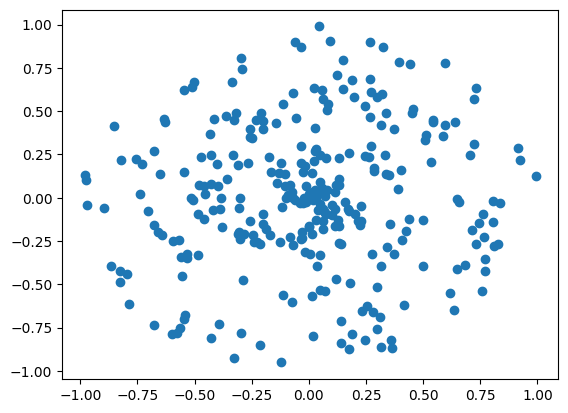

In [11]:
import matplotlib.pyplot as plt
from nnfs.datasets import spiral_data

X,y = spiral_data(samples=100, classes=3)

plt.scatter(X[:,0], X[:,1])
plt.show()

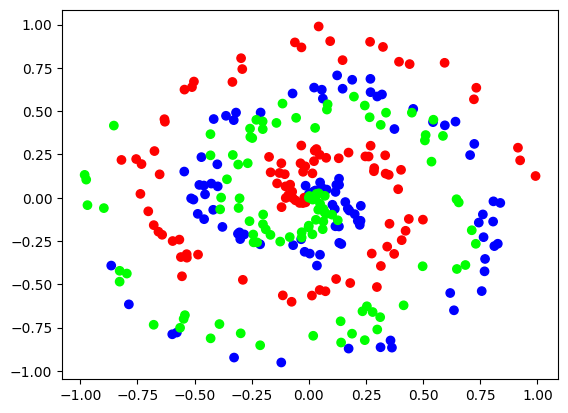

In [12]:
# add colours to make the chart more clear

plt.scatter(X[:,0], X[:,1], c=y, cmap="brg")
plt.show()

# Dense Layer Class 

Now that we no longer need to hand-type our data, we should create something similar for our 
various types of neural network layers. So far, we’ve only used what’s called a ​dense​ or 
fully-connected​ layer. These layers are commonly referred to as “dense” layers in papers, 
literature, and code, but you will occasionally see them called fully-connected or “fc” for short in 
code. Our dense layer class will begin with two methods.

In [13]:
class Layer_Dense:
    def __init__(self,n_inputs, n_neurons):
        # initialize weights and biases
        pass # just a placeholder for now, we'll fill this in later
    def forward(self, inputs):
        # calculate output values from inputs, weights and biases
        pass # just a placeholder for now, we'll fill this in later

To continue the ​Layer_Dense​ class’ code let’s add the random initialization of weights and 
biases:

In [14]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        # initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    # def forward(self, inputs):


## Weight & Bias Initialization

- `np.random.randn` → generates random numbers from a **Gaussian distribution** (mean=0, variance=1)
- Multiply weights by `0.01` → keeps initial values small so training isn't disrupted by huge starting values
- `np.zeros` → initializes biases as zeros (safe starting point)

### Why small weights?
If weights start too large, the updates during training become insignificant compared to the weights themselves → model learns slowly or not at all.

### Shape of weights array
- 1st dimension = number of **inputs**
- 2nd dimension = number of **neurons**

### Example
```python
weights = 0.01 * np.random.randn(n_inputs, n_neurons)
biases = np.zeros((1, n_neurons))
```

In [15]:
import numpy as np
import nnfs

nnfs.init()

print(np.random.randn(2,3))

[[ 1.7640524  0.4001572  0.978738 ]
 [ 2.2408931  1.867558  -0.9772779]]


In [16]:
print(np.zeros((2,5)))

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [17]:
# To see an example of how the weights and biases are initialized, we can create a layer with 4 inputs and 3 neurons:

import numpy as np
import nnfs 

nnfs.init()

n_inputs = 2
n_neurons = 3

weights = 0.01 * np.random.randn(n_inputs, n_neurons)
biases = np.zeros((1, n_neurons))

print(weights)
print(biases)

[[ 0.01764052  0.00400157  0.00978738]
 [ 0.02240893  0.01867558 -0.00977278]]
[[0. 0. 0.]]


In [18]:
# On to our forward method — we need to update it with the dot product+biases calculation: 
def forward(self, inputs):
    self.output = np.dot(inputs, self.weights) + self.biases
    

Nothing new here, just turning the previous code into a method. Our full ​Layer_Dense​ class so 
far:


In [25]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        # initialize weights and biases
        self.weights = 0.10 * np.random.rand(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        # calculate output values from inputs, weights and biases
        self.output = np.dot(inputs, self.weights) + self.biases


We’re ready to make use of this new class instead of hardcoded calculations, so let’s generate 
some data using the discussed dataset creation method and use our new layer to perform a 
forward pass:

In [26]:
X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(2,3)
dense1.forward(X)

print(dense1.output[:5])

[[ 0.          0.          0.        ]
 [ 0.00036568  0.00025402  0.00059182]
 [ 0.00010948  0.00020273  0.00061089]
 [ 0.00188911  0.00103356  0.00210307]
 [-0.00011632  0.00022765  0.00086778]]


In [27]:
# Code so far

import numpy as np
import nnfs
from nnfs.datasets import spiral_data

nnfs.init()

class LayerDense:
    def __init__(self, n_inputs, n_neurons):
        # initialize the weights and biases

        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    # Forward Pass
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases

X, y = spiral_data(samples=100, classes=3)

dense1 = LayerDense(2,3)
dense1.forward(X)
print(dense1.output[:5])


[[ 0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [-1.0475188e-04  1.1395361e-04 -4.7983500e-05]
 [-2.7414842e-04  3.1729150e-04 -8.6921798e-05]
 [-4.2188365e-04  5.2666257e-04 -5.5912682e-05]
 [-5.7707680e-04  7.1401405e-04 -8.9430439e-05]]
